# DEMO MODUL 5 (CASE STUDY / SCENARIO BMI vs CHOLESTEROL)

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

In [6]:
data = pd.read_csv("tugas5_ganjil.csv")
print("5 First row in dataset:")
print(data.head())
print("\nData type information:")
print(data.info())

5 First row in dataset:
   ID  Age  Gender Region  Blood_Pressure  Cholesterol   BMI  Heart_Rate Exercise_Level  Smoking Alcohol_Consumption  Diabetes  Family_History  Stress_Level  Heart_Attack  Angina  Heart_Disease_History       Diet  Sleep_Hours  Occupation Income_Level Physical_Activity Education_Level Marital_Status Urban_Rural  Medication  Health_Awareness  Daily_Water_Intake  Mental_Health  Obesity
0   1   50    Male  Rural          110.00       196.50 15.90          76           High    False            Moderate     False           False             8         False   False                  False  Unhealthy         9.40  Unemployed          Low               Low         Primary        Married       Rural       False                 5                2.30              5    False
1   2   40  Female  Urban          138.80       157.50 27.10          82       Moderate    False                 NaN     False            True             5         False    True                  False  U

## HANDLE MISSING VALUE USING SK-LEARN IMPUTER

In [7]:
missing_cols = ['Alcohol_Consumption'] 
categorical_imputer = SimpleImputer(strategy='most_frequent')
data[missing_cols] = categorical_imputer.fit_transform(data[missing_cols])
print("Missing values after preprocess:")
print(data.isna().sum())

Missing values after preprocess:
ID                       0
Age                      0
Gender                   0
Region                   0
Blood_Pressure           0
Cholesterol              0
BMI                      0
Heart_Rate               0
Exercise_Level           0
Smoking                  0
Alcohol_Consumption      0
Diabetes                 0
Family_History           0
Stress_Level             0
Heart_Attack             0
Angina                   0
Heart_Disease_History    0
Diet                     0
Sleep_Hours              0
Occupation               0
Income_Level             0
Physical_Activity        0
Education_Level          0
Marital_Status           0
Urban_Rural              0
Medication               0
Health_Awareness         0
Daily_Water_Intake       0
Mental_Health            0
Obesity                  0
dtype: int64


## CHOOSING WHAT DATA TO CLUSTER

In [8]:
data = (
    data[['BMI', 'Cholesterol']]
    .apply(pd.to_numeric, errors='coerce')
    .dropna()
)

print(data.head())

    BMI  Cholesterol
0 15.90       196.50
1 27.10       157.50
2 27.20       210.10
3 26.00       170.50
4 27.50       224.50


## NORMALIZATION

In [9]:
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data[['BMI', 'Cholesterol']])
data_normalized = pd.DataFrame(data_normalized, columns=['BMI', 'Cholesterol'], index=data.index)
data['BMI_normalized'] = data_normalized['BMI']
data['Cholesterol_normalized'] = data_normalized['Cholesterol']

print("\nAfter data normalization:")
print(data.head())


After data normalization:
    BMI  Cholesterol  BMI_normalized  Cholesterol_normalized
0 15.90       196.50           -1.82                   -0.07
1 27.10       157.50            0.42                   -0.85
2 27.20       210.10            0.44                    0.20
3 26.00       170.50            0.20                   -0.59
4 27.50       224.50            0.50                    0.49


# K-MEANS

### ELBOW METHOD

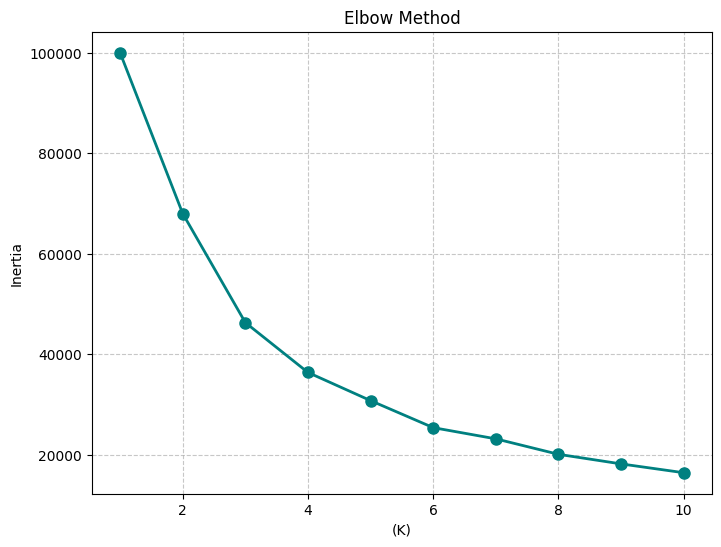

In [10]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_normalized[['BMI', 'Cholesterol']])
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'o-', color='teal', markersize=8, linewidth=2) 
plt.xlabel('(K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

### SILHOUETTE SCORES

Score for k=2: 0.3057
Score for k=3: 0.3262
Score for k=4: 0.3060
Score for k=5: 0.3025
Score for k=6: 0.3199
Score for k=7: 0.2970
Score for k=8: 0.3092
Score for k=9: 0.3080
Score for k=10: 0.3111


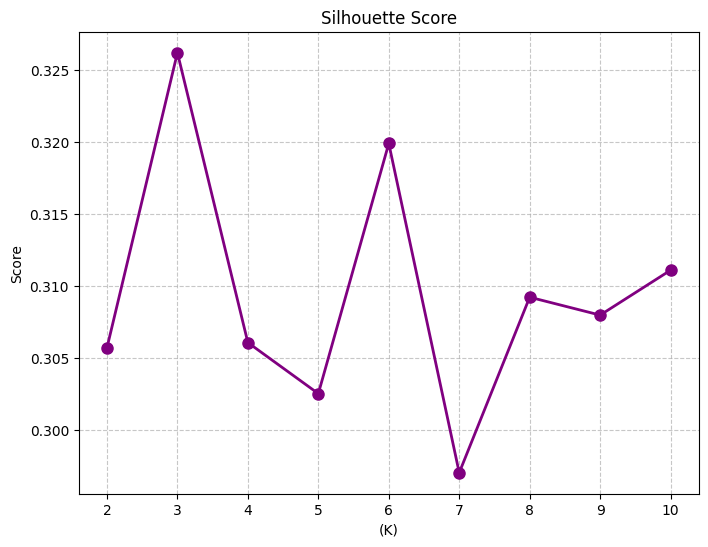

In [13]:
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_normalized[['BMI', 'Cholesterol']])
    score = silhouette_score(data_normalized[['BMI', 'Cholesterol']], kmeans.labels_)
    silhouette_scores.append(score)
    print(f'Score for k={k}: {score:.4f}')

# Visualisasi Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(K_range, silhouette_scores, 'o-', color='purple', markersize=8, linewidth=2)
plt.xlabel('(K)')
plt.ylabel('Score')
plt.title('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### GAP STATISTICS

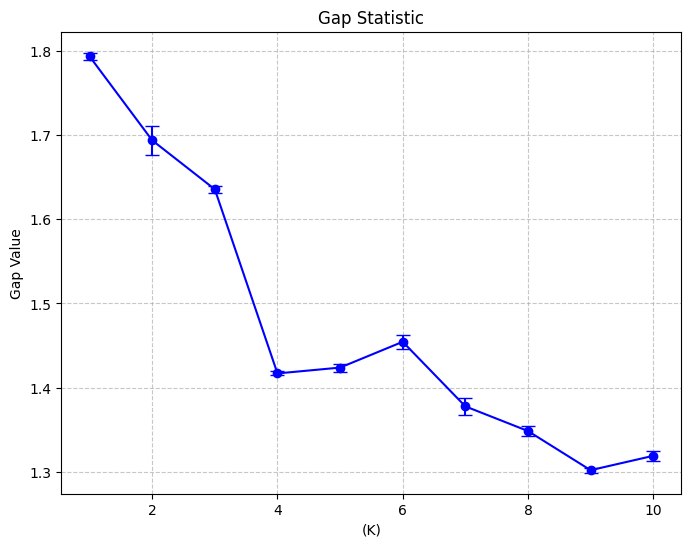

In [ ]:
def gap_statistic(data, k_max=10, n_refs=5):
    gaps = []  # Store gap values for each k
    sks = []   # Store standard error for each k

    for k in range(1, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42).fit(data)  # Fit KMeans model for current k
        Wk = np.log(kmeans.inertia_)  # Log of within-cluster sum of squares (inertia)

        Wk_refs = []
        for _ in range(n_refs):
            ref_data = np.random.uniform(data.min(0), data.max(0), data.shape)  # Generate random reference data
            Wk_refs.append(np.log(KMeans(n_clusters=k, random_state=42).fit(ref_data).inertia_))  # Log inertia for reference data

        gap = np.mean(Wk_refs) - Wk  # Calculate gap statistic: mean of reference log inertia minus actual log inertia
        sk = np.std(Wk_refs) * np.sqrt(1 + 1/n_refs)  # Calculate standard error for gap
        gaps.append(gap)
        sks.append(sk)

    optimal_k = next((k for k in range(2, k_max + 1) if gaps[k-2] - gaps[k-1] + sks[k-1] >= 0), k_max)  # Find optimal k where gap(k-1) >= gap(k) - sk(k)

    return gaps, sks, optimal_k

gaps, sks, optimal_k = gap_statistic(data_normalized[['BMI', 'Cholesterol']])  # Run gap statistic on normalized BMI and Cholesterol data

# Visualisasi Gap Statistic
plt.figure(figsize=(8, 6))  
plt.errorbar(range(1, 11), gaps, yerr=sks, fmt='bo-', capsize=5)  
plt.xlabel('(K)') 
plt.ylabel('Gap Value')  
plt.title('Gap Statistic') 
plt.grid(True, linestyle='--', alpha=0.7)  
plt.show()

### K-MEANS VISUALIZATION

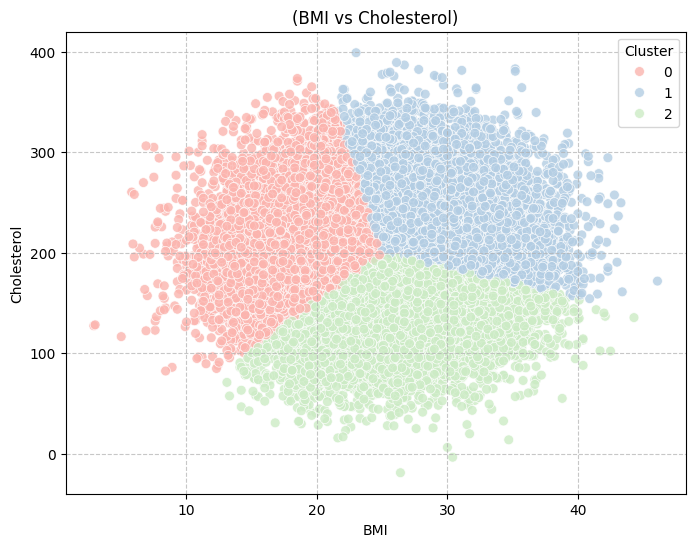

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(data_normalized[['BMI', 'Cholesterol']])

# Visualisasi hasil K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Cholesterol', hue='KMeans_Cluster', data=data,
                palette='Pastel1', s=50, alpha=0.8) 
plt.title('(BMI vs Cholesterol)')
plt.xlabel('BMI')
plt.ylabel('Cholesterol')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### DBSCAN

### FINDING EPS VALUE FOR DBSCAN CLUSTER

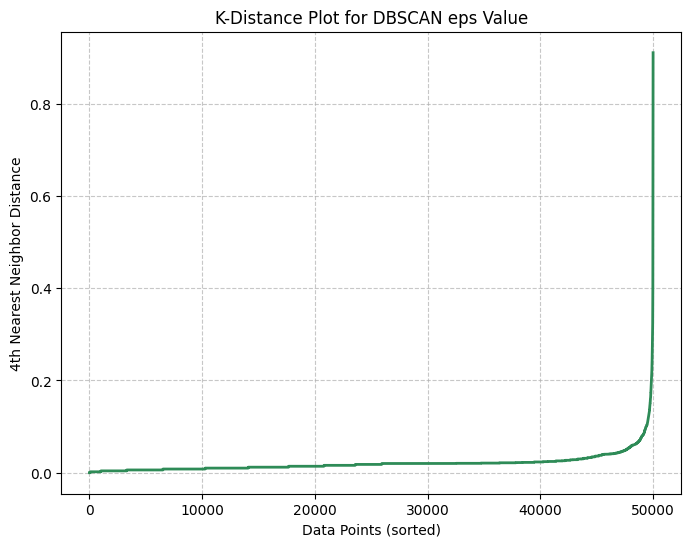

In [10]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(data_normalized[['BMI', 'Cholesterol']])
distances, indices = neighbors_fit.kneighbors(data_normalized[['BMI', 'Cholesterol']])

distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize=(8, 6))
plt.plot(distances, color='seagreen', linewidth=2)
plt.xlabel('Data Points (sorted)')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN eps Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

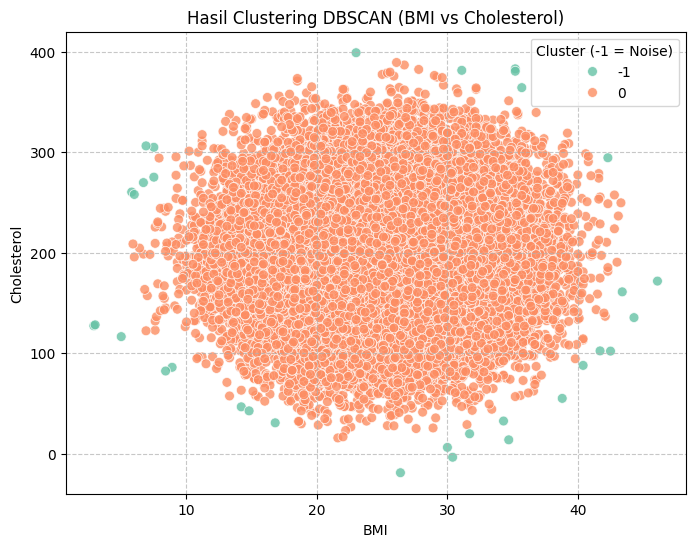

In [ ]:
# Note : Experiment (Silahkan ganti eps disini !)
dbscan = DBSCAN(eps=0.3, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(data_normalized[['BMI', 'Cholesterol']])

# Visualisasi hasil DBSCAN
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Cholesterol', hue='DBSCAN_Cluster', data=data,
                palette='Set2', s=50, alpha=0.8)
plt.title('DBSCAN Clustering Results (BMI vs Cholesterol)')
plt.xlabel('BMI')
plt.ylabel('Cholesterol')
plt.legend(title='Cluster (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [3]:
# Stats
print("\DBSCAN Results:")
print(f"Total Cluster (Not Including Noise): {len(np.unique(data['DBSCAN_Cluster'][data['DBSCAN_Cluster'] != -1]))}")
print(f"Total Noise: {len(data[data['DBSCAN_Cluster'] == -1])}")

\DBSCAN Results:


NameError: name 'np' is not defined

In [ ]:
# Difference
print("\nPerbandingan K-Means dan DBSCAN:")
print("- K-Means:")
print("  - Kelebihan: Mampu membagi data ke dalam kelompok yang terdefinisi dengan baik dan mudah dianalisis (contohnya: tiga kelompok berdasarkan BMI dan kolesterol). \n  Sangat cocok bila data tersebar secara merata.")
print("  - Kelemahan: Berasumsi bahwa bentuk cluster menyerupai lingkaran dan tidak memiliki toleransi terhadap outlier. Seluruh data akan tetap dimasukkan ke dalam suatu cluster.")
print("- DBSCAN:")
print("  - Kelebihan: Mampu mengenali data yang menyimpang (outlier) dan membentuk cluster yang tidak harus berbentuk simetris. Sangat membantu jika data memiliki pola tak beraturan.")
print("  - Kelemahan: Hasil sangat tergantung pada parameter seperti eps dan min_samples. Bila distribusi data tidak konsisten, DBSCAN cenderung menghasilkan banyak noise.")
print("- Kesimpulan Kontekstual: Untuk dataset ini, K-Means memberikan hasil yang lebih stabil karena data relatif tersebar merata dan kita ingin seluruh data diklasifikasikan. \n  Di sisi lain, DBSCAN efektif digunakan jika kita ingin mendeteksi anomali atau kelompok dengan karakteristik unik.")


Perbandingan K-Means dan DBSCAN:
- K-Means:
  - Kelebihan: Mampu membagi data ke dalam kelompok yang terdefinisi dengan baik dan mudah dianalisis (contohnya: tiga kelompok berdasarkan BMI dan kolesterol). 
  Sangat cocok bila data tersebar secara merata.
  - Kelemahan: Berasumsi bahwa bentuk cluster menyerupai lingkaran dan tidak memiliki toleransi terhadap outlier. Seluruh data akan tetap dimasukkan ke dalam suatu cluster.
- DBSCAN:
  - Kelebihan: Mampu mengenali data yang menyimpang (outlier) dan membentuk cluster yang tidak harus berbentuk simetris. Sangat membantu jika data memiliki pola tak beraturan.
  - Kelemahan: Hasil sangat tergantung pada parameter seperti eps dan min_samples. Bila distribusi data tidak konsisten, DBSCAN cenderung menghasilkan banyak noise.
- Kesimpulan Kontekstual: Untuk dataset ini, K-Means memberikan hasil yang lebih stabil karena data relatif tersebar merata dan kita ingin seluruh data diklasifikasikan. 
  Di sisi lain, DBSCAN efektif digunakan jika kit